# The Jacobian
**A rigorous treatment with code-driven visualisation**

### Sections
1. The Derivative as a Linear Map
2. The Jacobian Matrix — Definition & Structure
3. Special Cases (gradient, divergence, curl)
4. The Jacobian Determinant & Geometric Meaning
5. Chain Rule in Matrix Form
6. Visualisation — How $f$ Deforms Space
7. Jacobian Determinant as Area / Volume Scaling
8. Singular Jacobians & Rank Deficiency
9. Automatic Differentiation with PyTorch
10. Jacobians in Deep Learning — Backprop & Sensitivity

## 1 · The Derivative as a Linear Map

Let $f : \mathbb{R}^n \to \mathbb{R}^m$ be a function. The classical single-variable derivative $f'(x) \in \mathbb{R}$ satisfies:

$$f(x + h) = f(x) + f'(x)\,h + o(h) \quad \text{as } h \to 0$$

The generalisation to vector-valued functions replaces the scalar multiplier $f'(x)$ with a **linear map** $Df(\mathbf{x}) : \mathbb{R}^n \to \mathbb{R}^m$:

$$\boxed{f(\mathbf{x} + \mathbf{h}) = f(\mathbf{x}) + Df(\mathbf{x})\,\mathbf{h} + o(\|\mathbf{h}\|) \quad \text{as } \mathbf{h} \to \mathbf{0}}$$

This is the **Fréchet derivative** (or total derivative). The linear map $Df(\mathbf{x})$ is the best linear approximation to $f$ near $\mathbf{x}$.

**Fréchet differentiability.** $f$ is Fréchet-differentiable at $\mathbf{x}$ if there exists a bounded linear operator $L : \mathbb{R}^n \to \mathbb{R}^m$ such that:

$$\lim_{\mathbf{h} \to \mathbf{0}} \frac{\|f(\mathbf{x} + \mathbf{h}) - f(\mathbf{x}) - L\mathbf{h}\|}{\|\mathbf{h}\|} = 0$$

When it exists, $L$ is unique and we write $L = Df(\mathbf{x})$. In finite dimensions, every linear map has a matrix representation — the **Jacobian matrix**.

## 2 · The Jacobian Matrix

Let $f : \mathbb{R}^n \to \mathbb{R}^m$, written component-wise as:

$$f(\mathbf{x}) = \begin{pmatrix} f_1(x_1, \ldots, x_n) \\ \vdots \\ f_m(x_1, \ldots, x_n) \end{pmatrix}$$

The **Jacobian** of $f$ at $\mathbf{x}$ is the $m \times n$ matrix of all first-order partial derivatives:

$$J_f(\mathbf{x}) = Df(\mathbf{x}) = \frac{\partial f}{\partial \mathbf{x}} = \begin{pmatrix}
\dfrac{\partial f_1}{\partial x_1} & \cdots & \dfrac{\partial f_1}{\partial x_n} \\[8pt]
\vdots & \ddots & \vdots \\[4pt]
\dfrac{\partial f_m}{\partial x_1} & \cdots & \dfrac{\partial f_m}{\partial x_n}
\end{pmatrix}$$

**Entry interpretation:** $(J_f)_{ij} = \partial f_i / \partial x_j$ — the rate of change of output $i$ with respect to input $j$, holding all other inputs fixed.

**Row $i$:** the gradient of the scalar function $f_i$, i.e. $\nabla f_i^\top$.

**Column $j$:** the directional derivative of $f$ along $\mathbf{e}_j$.

### Existence vs. Differentiability

All partial derivatives existing at $\mathbf{x}$ does **not** imply Fréchet differentiability. A sufficient condition: all partials exist and are **continuous** in a neighbourhood of $\mathbf{x}$ (i.e. $f \in C^1$). When $f$ is $C^1$, $J_f$ exists everywhere and equals the Fréchet derivative.

## 3 · Special Cases

### Gradient ($m=1$, $f : \mathbb{R}^n \to \mathbb{R}$)
$$J_f = \nabla f^\top = \begin{pmatrix} \frac{\partial f}{\partial x_1} & \cdots & \frac{\partial f}{\partial x_n} \end{pmatrix} \in \mathbb{R}^{1 \times n}$$
The gradient is the transpose of the Jacobian row vector.

### Jacobian of an Affine Map
If $f(\mathbf{x}) = A\mathbf{x} + \mathbf{b}$, then $J_f(\mathbf{x}) = A$ everywhere. The Jacobian of a linear map is the map itself.

### Hessian ($m=1$, second order)
The Hessian $H_f = J_{\nabla f}$ — the Jacobian of the gradient:
$$H_f(\mathbf{x})_{ij} = \frac{\partial^2 f}{\partial x_i \partial x_j}$$
Symmetric when $f \in C^2$ (Schwarz's theorem).

### Divergence ($m=n$, $f : \mathbb{R}^n \to \mathbb{R}^n$)
$$\text{div}\, f = \text{tr}(J_f) = \sum_{i=1}^n \frac{\partial f_i}{\partial x_i}$$
The trace of the Jacobian equals the divergence — the net outward flux per unit volume.

### Curl ($n=m=3$)
The curl of $f = (f_1, f_2, f_3)$ equals the skew-symmetric part of $J_f$:
$$\nabla \times f = \begin{pmatrix} \partial_2 f_3 - \partial_3 f_2 \\ \partial_3 f_1 - \partial_1 f_3 \\ \partial_1 f_2 - \partial_2 f_1 \end{pmatrix}$$

## 4 · The Jacobian Determinant

When $f : \mathbb{R}^n \to \mathbb{R}^n$ (square Jacobian), the **Jacobian determinant** $\det J_f(\mathbf{x})$ captures the local behaviour of $f$ as a change of variables.

### Change of Variables Formula

If $f : U \subseteq \mathbb{R}^n \to \mathbb{R}^n$ is a $C^1$ diffeomorphism:

$$\int_{f(U)} g(\mathbf{y})\, d\mathbf{y} = \int_U g(f(\mathbf{x}))\, |\det J_f(\mathbf{x})|\, d\mathbf{x}$$

### Geometric Interpretation

$|\det J_f(\mathbf{x})|$ is the **local volume scaling factor**: an infinitesimal region of volume $dV$ near $\mathbf{x}$ maps to a region of volume $|\det J_f(\mathbf{x})|\, dV$ near $f(\mathbf{x})$.

| $\det J_f$ | Meaning |
|---|---|
| $> 1$ | $f$ expands volume locally |
| $(0, 1)$ | $f$ contracts volume locally |
| $= 1$ | $f$ is volume-preserving (e.g. rotation) |
| $< 0$ | $f$ reverses orientation (reflection component) |
| $= 0$ | $f$ is locally singular — collapses a dimension |

### Inverse Function Theorem

If $f$ is $C^1$ and $\det J_f(\mathbf{x}_0) \neq 0$, then $f$ is a local diffeomorphism near $\mathbf{x}_0$: there exist open sets $U \ni \mathbf{x}_0$ and $V \ni f(\mathbf{x}_0)$ such that $f|_U : U \to V$ is invertible with $C^1$ inverse, and:

$$J_{f^{-1}}(f(\mathbf{x})) = J_f(\mathbf{x})^{-1}$$

## 5 · Chain Rule in Matrix Form

Let $g : \mathbb{R}^n \to \mathbb{R}^k$ and $f : \mathbb{R}^k \to \mathbb{R}^m$, with $h = f \circ g$. Then:

$$\boxed{J_h(\mathbf{x}) = J_f(g(\mathbf{x})) \cdot J_g(\mathbf{x})}$$

Dimensions: $(m \times k) \cdot (k \times n) = m \times n$. ✓

Entry-wise (summing over the intermediate dimension $k$):

$$\frac{\partial h_i}{\partial x_j} = \sum_{\ell=1}^k \frac{\partial f_i}{\partial g_\ell} \cdot \frac{\partial g_\ell}{\partial x_j}$$

This is exactly the scalar chain rule, applied simultaneously to every $(i, j)$ pair.

### Deep Network Chain Rule

For a network $h = f^{(L)} \circ \cdots \circ f^{(1)}$:

$$J_h = J_{f^{(L)}}(\mathbf{h}^{(L-1)}) \cdot J_{f^{(L-1)}}(\mathbf{h}^{(L-2)}) \cdots J_{f^{(1)}}(\mathbf{x})$$

The gradient of a scalar loss $\mathcal{L}$ with respect to layer inputs propagates as:

$$\nabla_{\mathbf{h}^{(\ell)}} \mathcal{L} = J_{f^{(\ell+1)}}^\top \cdot \nabla_{\mathbf{h}^{(\ell+1)}} \mathcal{L}$$

Backpropagation is sequential evaluation of this product — right-to-left — exploiting the fact that computing $\mathbf{v}^\top J$ (a vector-Jacobian product, VJP) is as cheap as a single forward pass.

## 6 · Setup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import torch
import torch.nn as nn

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


def grid(n=20, lo=-2, hi=2):
    """Return a meshgrid over [lo,hi]^2."""
    t = np.linspace(lo, hi, n)
    return np.meshgrid(t, t)


print("ready")

ready


## 7 · Visualisation — How $f$ Deforms Space

We plot a regular grid under several maps $f : \mathbb{R}^2 \to \mathbb{R}^2$ to see how the Jacobian predicts local stretching and rotation.

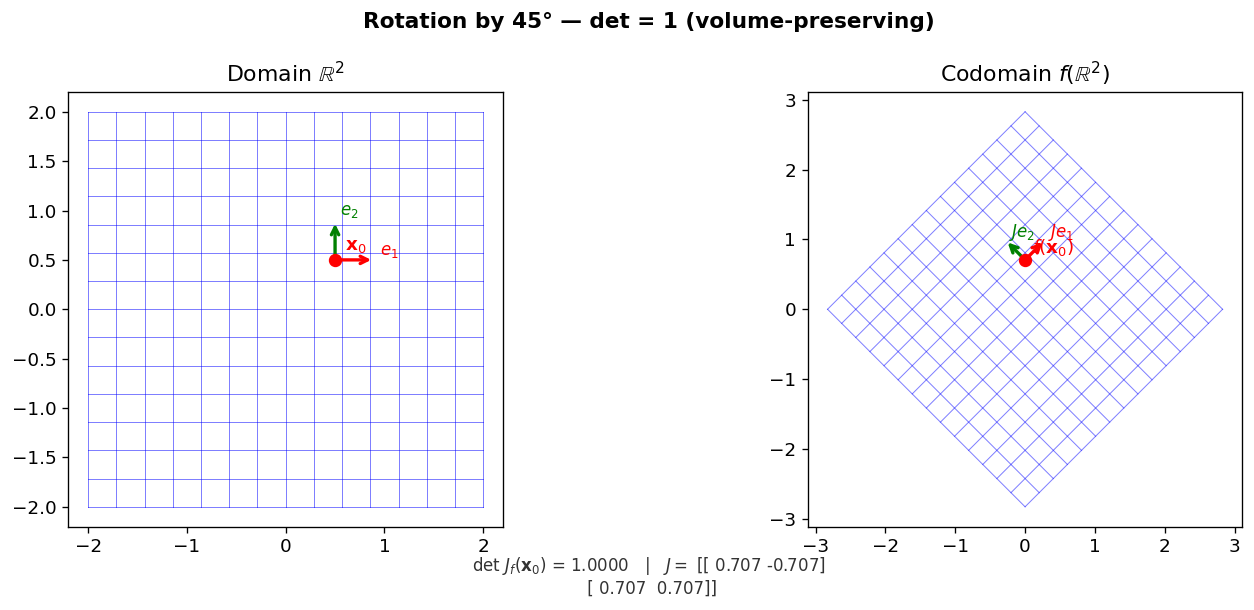

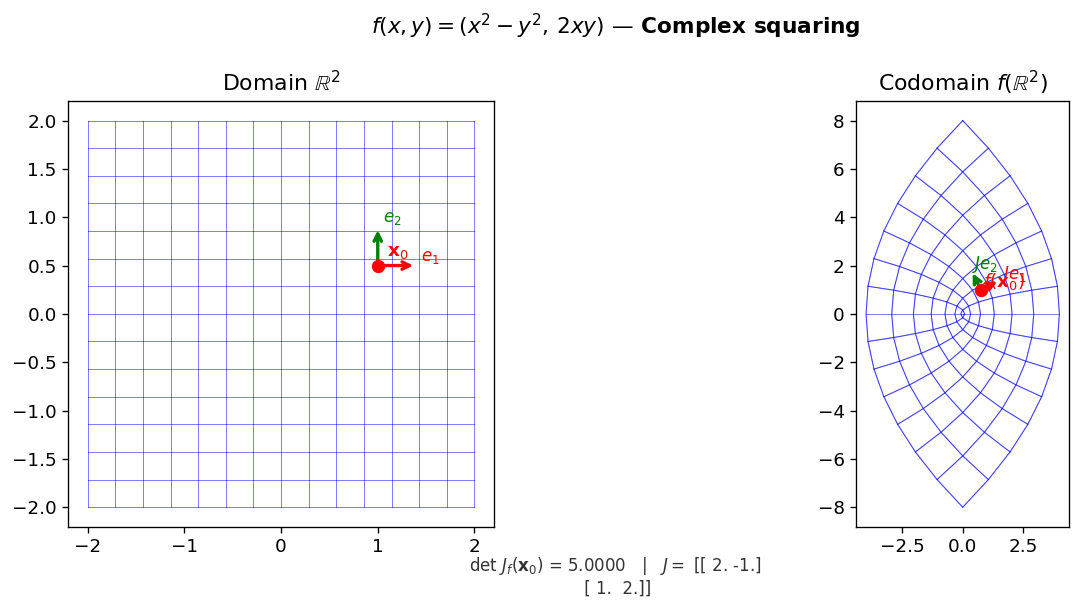

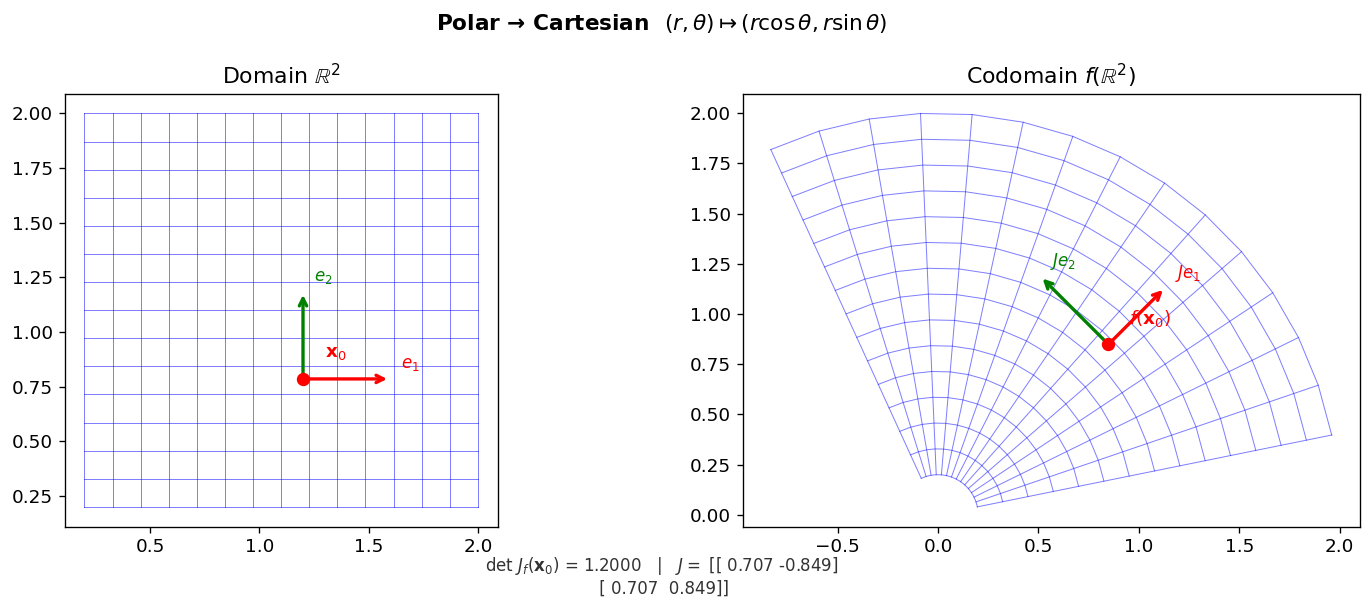

In [ ]:
def plot_deformation(f, J_fn, title, lo=-2, hi=2, n=15, x0=np.array([0.5, 0.5])):
    """
    Left : original grid + point x0
    Right: deformed grid, tangent vectors from J_fn(x0), and image f(x0)
    """
    t = np.linspace(lo, hi, n)
    X, Y = np.meshgrid(t, t)
    pts = np.stack([X.ravel(), Y.ravel()], axis=1)  # (n^2, 2)
    fpts = np.array([f(p) for p in pts])
    FX = fpts[:, 0].reshape(n, n)
    FY = fpts[:, 1].reshape(n, n)

    J = J_fn(x0)  # 2×2 Jacobian at x0
    fx0 = f(x0)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for ax, (gx, gy), label in zip(
        axes,
        [(X, Y), (FX, FY)],
        ["Domain $\\mathbb{R}^2$", "Codomain $f(\\mathbb{R}^2)$"],
    ):
        for row in range(n):
            ax.plot(gx[row, :], gy[row, :], "b-", lw=0.6, alpha=0.5)
            ax.plot(gx[:, row], gy[:, row], "b-", lw=0.6, alpha=0.5)
        ax.set_aspect("equal")
        ax.set_title(label)
        ax.grid(False)

    # original point + basis vectors
    scale = 0.4
    axes[0].plot(*x0, "ro", ms=7, zorder=5)
    axes[0].annotate("$\\mathbf{x}_0$", x0, xytext=x0 + 0.1, fontsize=11, color="r")
    for vec, col, lbl in zip(np.eye(2), ["red", "green"], ["$e_1$", "$e_2$"]):
        axes[0].annotate(
            "",
            xy=x0 + scale * vec,
            xytext=x0,
            arrowprops=dict(arrowstyle="->", color=col, lw=2),
        )
        axes[0].text(*(x0 + scale * vec + 0.05), lbl, color=col, fontsize=10)

    # image point + Jacobian columns (tangent vectors)
    axes[1].plot(*fx0, "ro", ms=7, zorder=5)
    axes[1].annotate(
        "$f(\\mathbf{x}_0)$", fx0, xytext=fx0 + 0.1, fontsize=11, color="r"
    )
    for j, (col, lbl) in enumerate(zip(["red", "green"], ["$J e_1$", "$J e_2$"])):
        vec = scale * J[:, j]
        axes[1].annotate(
            "",
            xy=fx0 + vec,
            xytext=fx0,
            arrowprops=dict(arrowstyle="->", color=col, lw=2),
        )
        axes[1].text(*(fx0 + vec + 0.05), lbl, color=col, fontsize=10)

    det = np.linalg.det(J)
    fig.text(
        0.5,
        0.01,
        f"det $J_f(\\mathbf{{x}}_0)$ = {det:.4f}   |   "
        f"$J = $ {np.array2string(J, precision=3, suppress_small=True)}",
        ha="center",
        fontsize=10,
        color="#333",
    )
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.show()


# ── 1. Rotation by θ ────────────────────────────────────────────────────────
theta = np.pi / 4
R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])

plot_deformation(
    f=lambda x: R @ x,
    J_fn=lambda x: R,
    title="Rotation by 45° — det = 1 (volume-preserving)",
)


# ── 2. Nonlinear: f(x,y) = (x²−y², 2xy)  [complex squaring] ────────────────
def f_sq(x):
    return np.array([x[0] ** 2 - x[1] ** 2, 2 * x[0] * x[1]])


def J_sq(x):
    return np.array([[2 * x[0], -2 * x[1]], [2 * x[1], 2 * x[0]]])


plot_deformation(
    f_sq,
    J_sq,
    title="$f(x,y)=(x^2-y^2,\\, 2xy)$ — Complex squaring",
    x0=np.array([1.0, 0.5]),
)


# ── 3. Polar-to-Cartesian ────────────────────────────────────────────────────
def f_pol(x):
    return np.array([x[0] * np.cos(x[1]), x[0] * np.sin(x[1])])


def J_pol(x):
    return np.array(
        [[np.cos(x[1]), -x[0] * np.sin(x[1])], [np.sin(x[1]), x[0] * np.cos(x[1])]]
    )


plot_deformation(
    f_pol,
    J_pol,
    title="Polar → Cartesian  $(r,\\theta) \\mapsto (r\\cos\\theta, r\\sin\\theta)$",
    lo=0.2,
    hi=2.0,
    x0=np.array([1.2, np.pi / 4]),
)

## 8 · Jacobian Determinant as Area / Volume Scaling

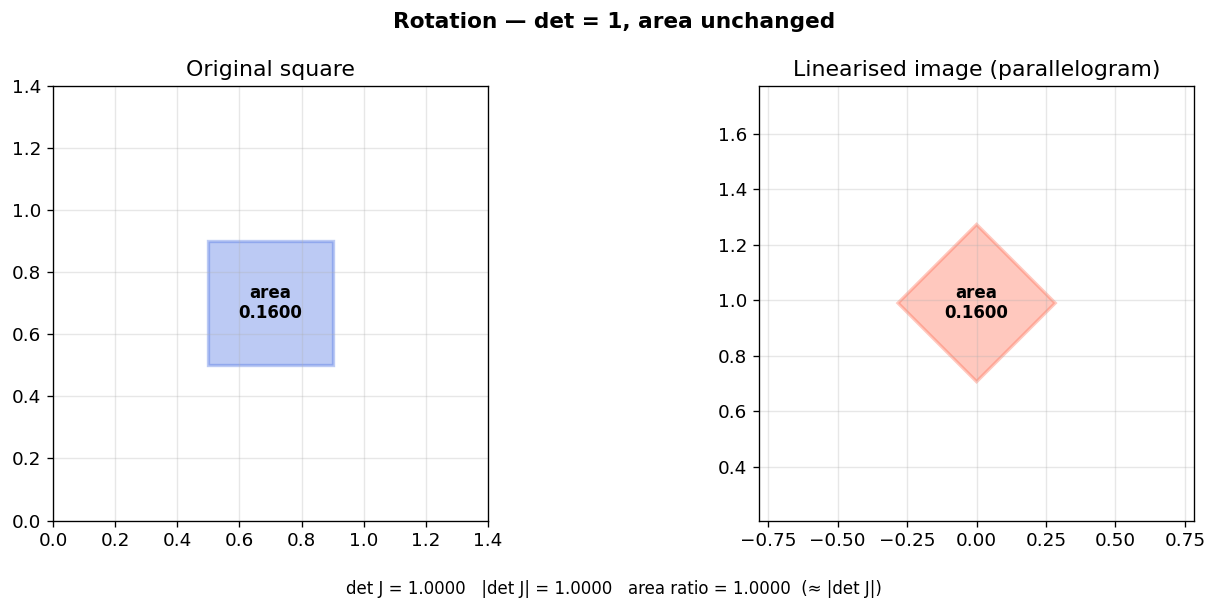

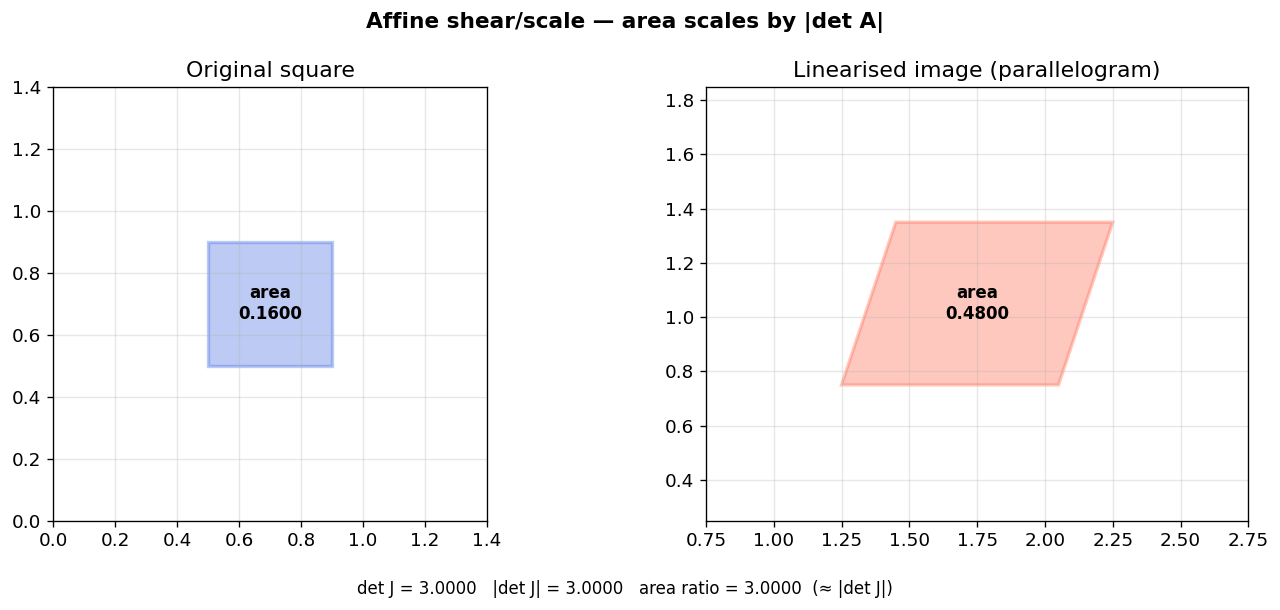

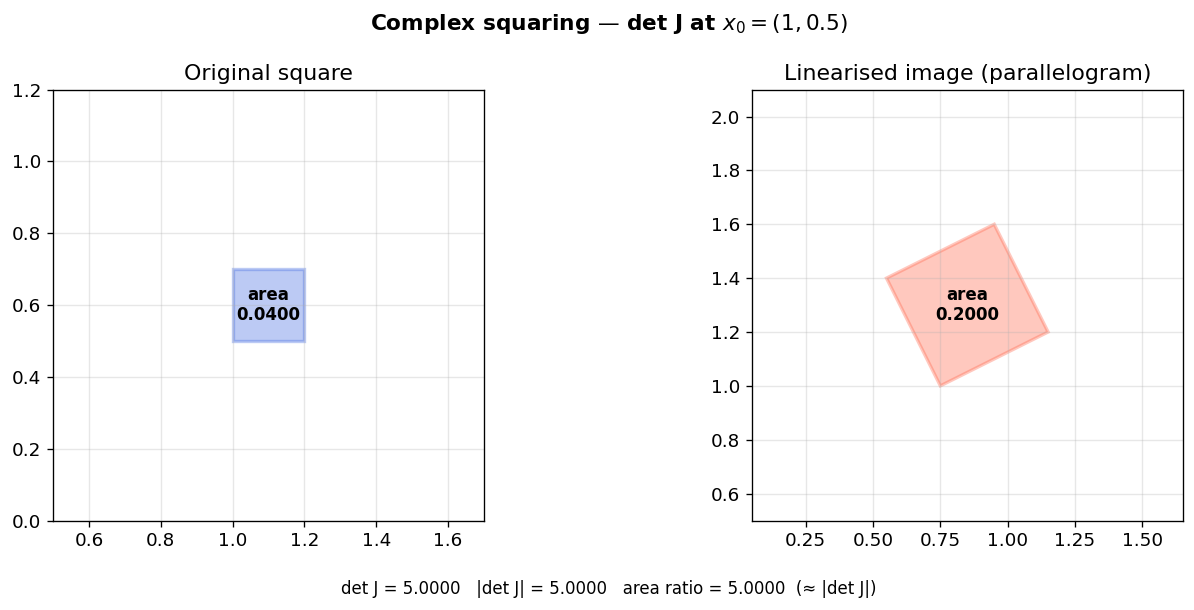

In [ ]:
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection


def show_area_scaling(f, J_fn, title, x0=np.array([0.5, 0.5]), eps=0.4):
    """Draw a small parallelogram at x0 and its image under f, coloured by |det J|."""
    J = J_fn(x0)
    det = np.linalg.det(J)

    # corners of the unit square scaled by eps
    corners_dom = np.array(
        [
            x0,
            x0 + eps * np.array([1, 0]),
            x0 + eps * np.array([1, 1]),
            x0 + eps * np.array([0, 1]),
        ]
    )
    # image via first-order approximation: f(x0) + J*(corner - x0)
    corners_cod = np.array([f(x0) + J @ (c - x0) for c in corners_dom])
    exact_cod = np.array([f(c) for c in corners_dom])  # exact image

    area_dom = eps**2
    # area of the parallelogram spanned by J*e1 and J*e2
    v1, v2 = eps * J[:, 0], eps * J[:, 1]
    area_cod = abs(v1[0] * v2[1] - v1[1] * v2[0])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(title, fontweight="bold", fontsize=13)

    for ax, corners, clr, lbl, area in [
        (axes[0], corners_dom, "royalblue", "Original square", area_dom),
        (axes[1], corners_cod, "tomato", "Linearised image (parallelogram)", area_cod),
    ]:
        poly = MplPolygon(
            corners, closed=True, facecolor=clr, alpha=0.35, edgecolor=clr, lw=2
        )
        ax.add_patch(poly)
        cx, cy = corners.mean(axis=0)
        ax.text(
            cx,
            cy,
            f"area\n{area:.4f}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
        )
        ax.set_xlim(corners[:, 0].min() - 0.5, corners[:, 0].max() + 0.5)
        ax.set_ylim(corners[:, 1].min() - 0.5, corners[:, 1].max() + 0.5)
        ax.set_aspect("equal")
        ax.set_title(lbl)
        ax.grid(True, alpha=0.3)

    fig.text(
        0.5,
        0.01,
        f"det J = {det:.4f}   |det J| = {abs(det):.4f}   "
        f"area ratio = {area_cod/area_dom:.4f}  (≈ |det J|)",
        ha="center",
        fontsize=10,
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


# Rotation (det = 1)
show_area_scaling(
    lambda x: R @ x, lambda x: R, title="Rotation — det = 1, area unchanged"
)

# Shear + scale (det > 1)
A = np.array([[2.0, 0.5], [0.0, 1.5]])
show_area_scaling(
    lambda x: A @ x, lambda x: A, title="Affine shear/scale — area scales by |det A|"
)

# Complex squaring (nonlinear, det varies with position)
show_area_scaling(
    f_sq,
    J_sq,
    title="Complex squaring — det J at $x_0=(1, 0.5)$",
    x0=np.array([1.0, 0.5]),
    eps=0.2,
)

## 9 · |det J| as a Heatmap over the Plane

Plot $|\det J_f(\mathbf{x})|$ at every point — bright regions expand area, dark regions contract it.

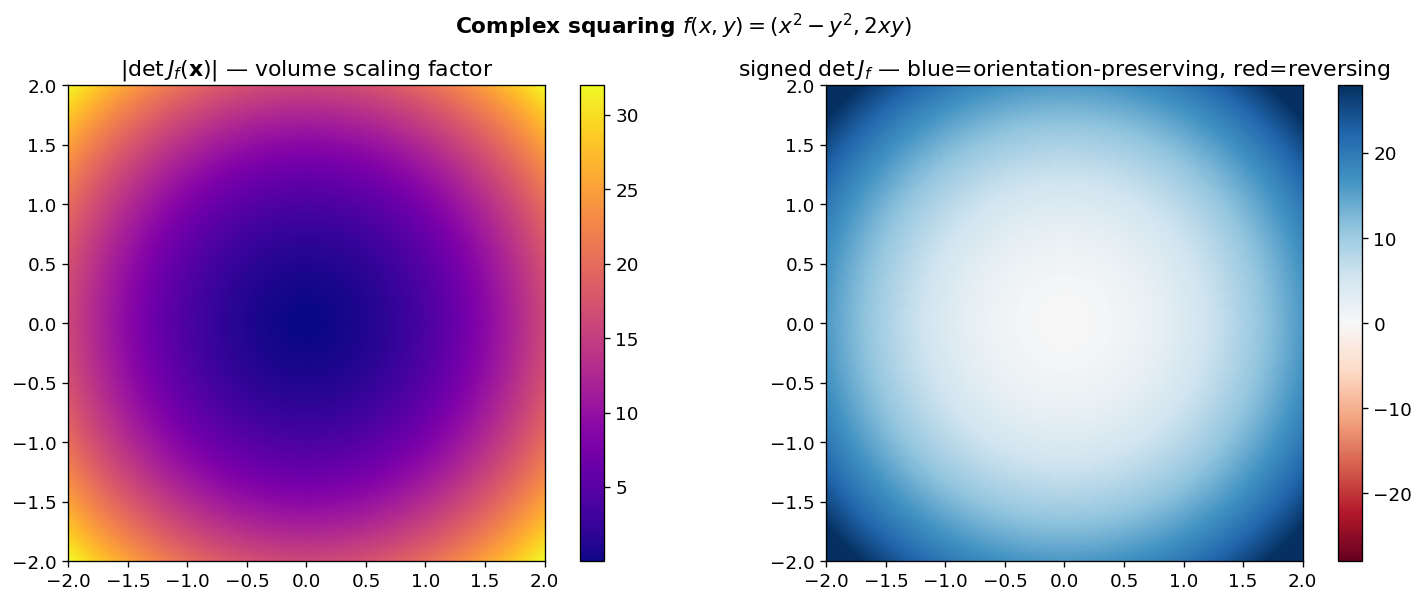

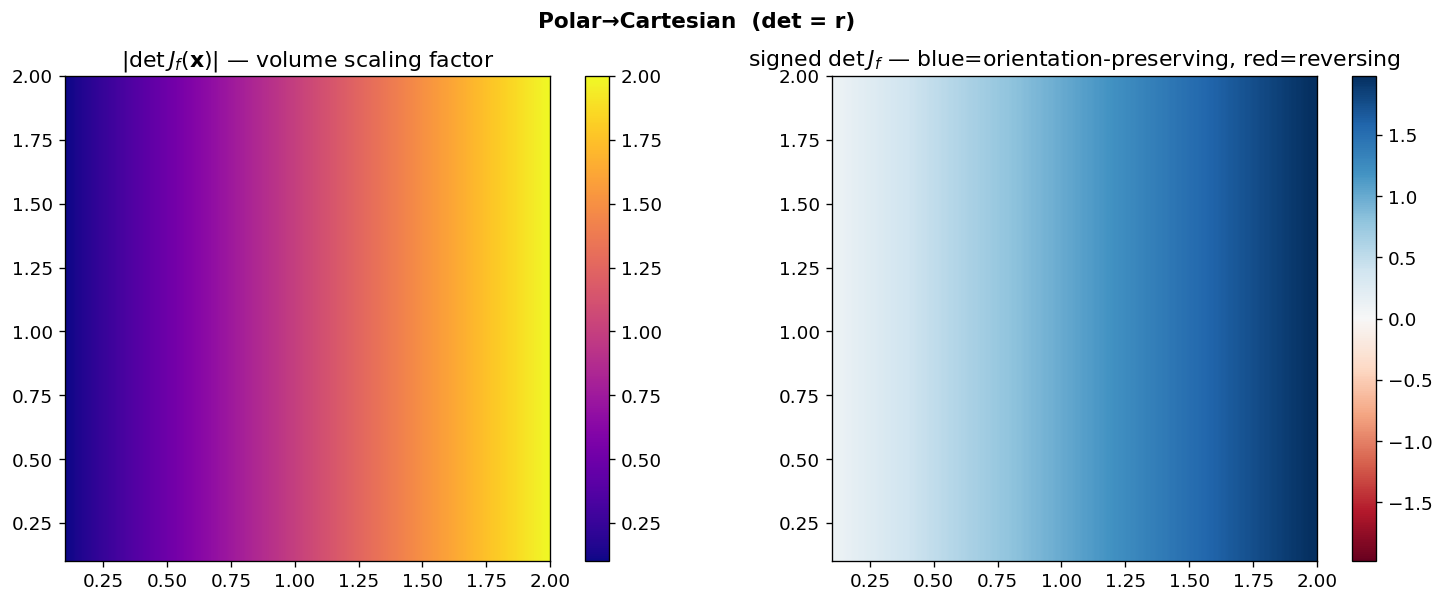

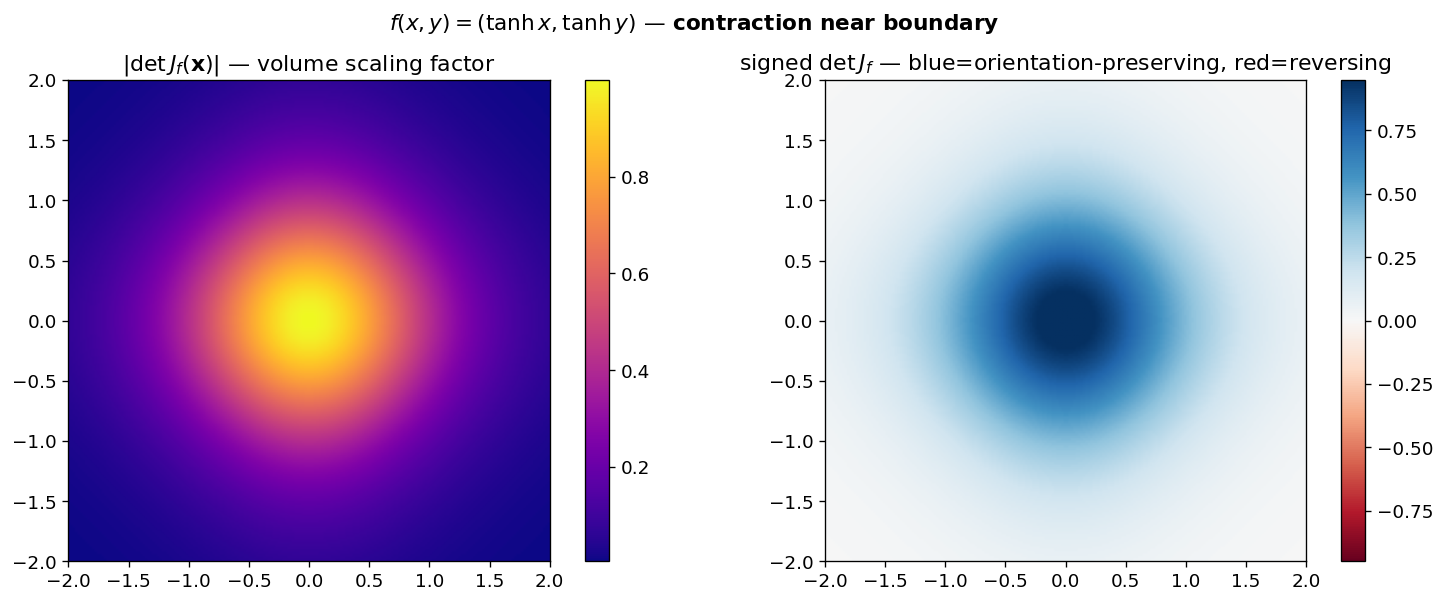

In [ ]:
def det_heatmap(J_fn, title, lo=-2, hi=2, n=200):
    t = np.linspace(lo, hi, n)
    X, Y = np.meshgrid(t, t)
    pts = np.stack([X.ravel(), Y.ravel()], axis=1)
    dets = np.array([np.linalg.det(J_fn(p)) for p in pts]).reshape(n, n)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontweight="bold", fontsize=13)

    im0 = axes[0].imshow(
        np.abs(dets),
        extent=[lo, hi, lo, hi],
        origin="lower",
        cmap="plasma",
        aspect="equal",
    )
    axes[0].set_title("$|\\det J_f(\\mathbf{x})|$ — volume scaling factor")
    plt.colorbar(im0, ax=axes[0])

    # signed det — orientation
    vmax = np.percentile(np.abs(dets), 99)
    im1 = axes[1].imshow(
        dets,
        extent=[lo, hi, lo, hi],
        origin="lower",
        cmap="RdBu",
        aspect="equal",
        vmin=-vmax,
        vmax=vmax,
    )
    axes[1].set_title("signed $\\det J_f$ — blue=orientation-preserving, red=reversing")
    plt.colorbar(im1, ax=axes[1])
    axes[1].contour(X, Y, dets, levels=[0], colors="k", linewidths=1.5)

    plt.tight_layout()
    plt.show()


det_heatmap(J_sq, title="Complex squaring $f(x,y)=(x^2-y^2, 2xy)$")
det_heatmap(J_pol, title="Polar→Cartesian  (det = r)", lo=0.1, hi=2.0)


# Tanh squashing map — contracts near the boundary
def J_tanh2d(x):
    return np.diag([1 - np.tanh(x[0]) ** 2, 1 - np.tanh(x[1]) ** 2])


det_heatmap(J_tanh2d, title="$f(x,y)=(\\tanh x, \\tanh y)$ — contraction near boundary")

## 10 · Singular Jacobians & Rank Deficiency

When $\text{rank}(J_f(\mathbf{x})) < \min(m, n)$, the map locally collapses at least one dimension.

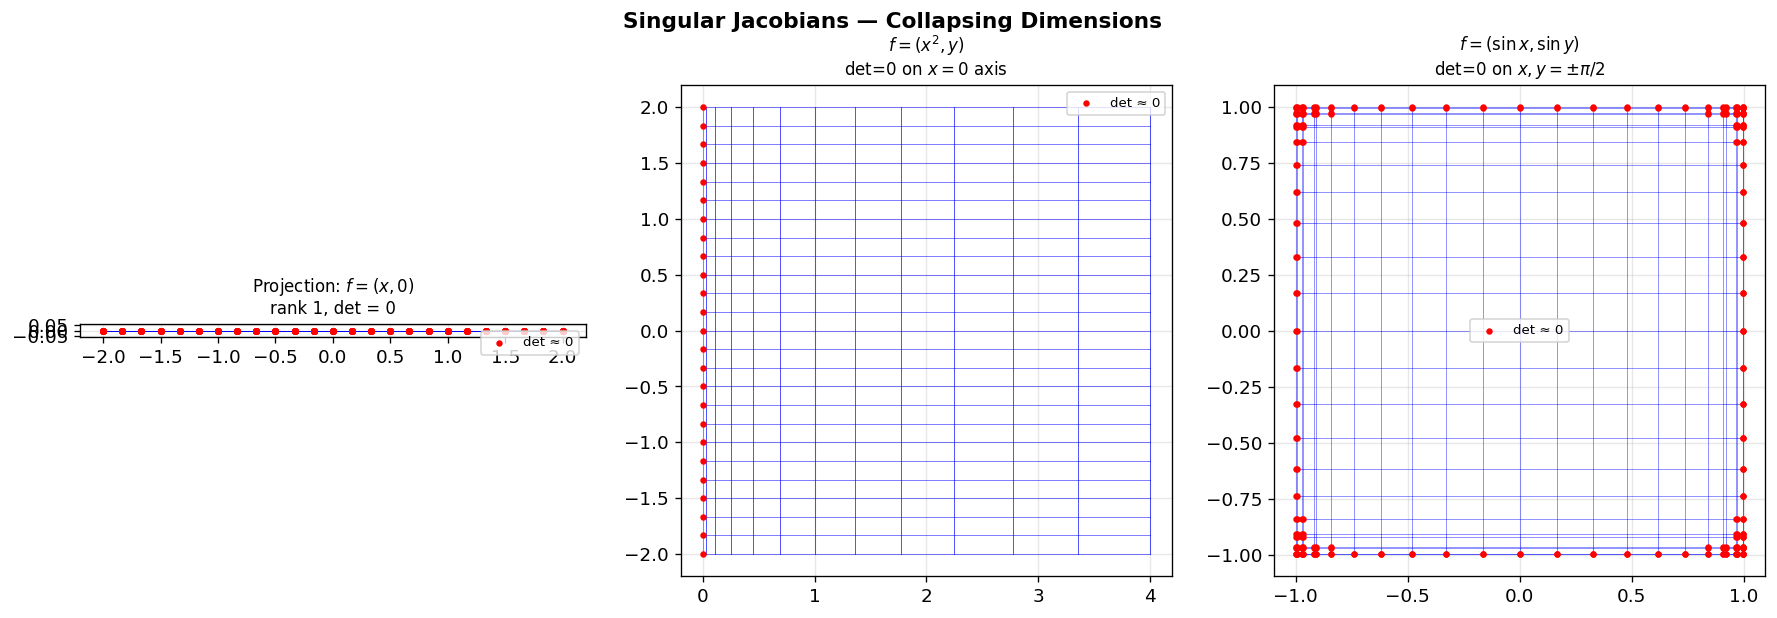

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Singular Jacobians — Collapsing Dimensions", fontweight="bold", fontsize=13
)

t = np.linspace(-2, 2, 25)
X, Y = np.meshgrid(t, t)

maps = [
    # f collapses y → 1D line (rank 1)
    (
        lambda x: np.array([x[0], 0.0]),
        lambda x: np.array([[1.0, 0.0], [0.0, 0.0]]),
        "Projection: $f=(x,0)$\nrank 1, det = 0",
    ),
    # f : R^2 -> R^2, det=0 along x=0
    (
        lambda x: np.array([x[0] ** 2, x[1]]),
        lambda x: np.array([[2 * x[0], 0.0], [0.0, 1.0]]),
        "$f=(x^2,y)$\ndet=0 on $x=0$ axis",
    ),
    # f = (sin x, sin y) — many zeros
    (
        lambda x: np.array([np.sin(x[0]), np.sin(x[1])]),
        lambda x: np.diag([np.cos(x[0]), np.cos(x[1])]),
        "$f=(\\sin x, \\sin y)$\ndet=0 on $x,y = \\pm\\pi/2$",
    ),
]

for ax, (f, J_fn, title) in zip(axes, maps):
    pts = np.stack([X.ravel(), Y.ravel()], axis=1)
    fpts = np.array([f(p) for p in pts])
    FX = fpts[:, 0].reshape(25, 25)
    FY = fpts[:, 1].reshape(25, 25)

    dets = np.array([np.linalg.det(J_fn(p)) for p in pts]).reshape(25, 25)

    for row in range(25):
        ax.plot(FX[row, :], FY[row, :], "b-", lw=0.5, alpha=0.5)
        ax.plot(FX[:, row], FY[:, row], "b-", lw=0.5, alpha=0.5)

    # mark where det ≈ 0
    zero_mask = np.abs(dets) < 0.15
    ax.scatter(FX[zero_mask], FY[zero_mask], c="red", s=8, zorder=5, label="det ≈ 0")
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11 · Numerical Jacobian vs. Analytical

In [ ]:
def numerical_jacobian(f, x, eps=1e-5):
    """Central-difference Jacobian. O(n) forward passes."""
    n = len(x)
    m = len(f(x))
    J = np.zeros((m, n))
    for j in range(n):
        e = np.zeros(n)
        e[j] = eps
        J[:, j] = (f(x + e) - f(x - e)) / (2 * eps)
    return J


# Test on several functions at several points
test_cases = [
    ("complex sq", f_sq, J_sq, np.array([1.0, 0.5])),
    ("polar→cart", f_pol, J_pol, np.array([1.5, np.pi / 3])),
    (
        "tanh^2",
        lambda x: np.array([np.tanh(x[0]), np.tanh(x[1])]),
        J_tanh2d,
        np.array([0.3, -1.2]),
    ),
]

print(f"{'Function':<14} {'x':<22} {'Max |J_analytic - J_numeric|':>30}")
print("-" * 70)
for name, f, J_fn, x in test_cases:
    Ja = J_fn(x)
    Jn = numerical_jacobian(f, x)
    err = np.max(np.abs(Ja - Jn))
    print(f"{name:<14} {str(np.round(x, 3)):<22} {err:>30.2e}")

Function       x                        Max |J_analytic - J_numeric|
----------------------------------------------------------------------
complex sq     [1.  0.5]                                    3.55e-12
polar→cart     [1.5   1.047]                                1.73e-11
tanh^2         [ 0.3 -1.2]                                  2.23e-11


## 12 · Automatic Differentiation with PyTorch

PyTorch computes exact Jacobians via reverse-mode AD. `torch.autograd.functional.jacobian` returns the full $m \times n$ matrix.

In [ ]:
import torch
from torch.autograd.functional import jacobian as torch_jacobian


# ── Example 1: simple nonlinear map ─────────────────────────────────────────
def f_torch(x):
    return torch.stack([x[0] ** 2 - x[1] ** 2, 2 * x[0] * x[1]])


x0_t = torch.tensor([1.0, 0.5], requires_grad=True)
J_ad = torch_jacobian(f_torch, x0_t)

J_analytic = J_sq(np.array([1.0, 0.5]))

print("PyTorch Jacobian (AD):")
print(J_ad.numpy())
print("\nAnalytic Jacobian:")
print(J_analytic)
print(f"\nMax error: {np.max(np.abs(J_ad.numpy() - J_analytic)):.2e}")

PyTorch Jacobian (AD):
[[ 2. -1.]
 [ 1.  2.]]

Analytic Jacobian:
[[ 2. -1.]
 [ 1.  2.]]

Max error: 0.00e+00


In [ ]:
# ── Example 2: Jacobian of a neural network layer ────────────────────────────
torch.manual_seed(0)

layer = nn.Sequential(
    nn.Linear(4, 8),
    nn.Tanh(),
    nn.Linear(8, 3),
)

x_in = torch.randn(4)


def net_fn(x):
    return layer(x)


J_net = torch_jacobian(net_fn, x_in)  # shape (3, 4)

print(f"Network input dim : 4")
print(f"Network output dim: 3")
print(f"Jacobian shape    : {J_net.shape}   (outputs × inputs)")
print(f"\nJacobian matrix:")
print(J_net.detach().numpy().round(4))
print(f"\nSingular values   : {torch.linalg.svdvals(J_net).detach().numpy().round(4)}")
print(
    f"det not defined (non-square); rank estimate: {torch.linalg.matrix_rank(J_net).item()}"
)

Network input dim : 4
Network output dim: 3
Jacobian shape    : torch.Size([3, 4])   (outputs × inputs)

Jacobian matrix:
[[-0.0566 -0.0996  0.1779 -0.0699]
 [-0.0144  0.0177  0.0848 -0.1689]
 [ 0.1232  0.0732 -0.1482  0.077 ]]

Singular values   : [0.3358 0.1363 0.055 ]
det not defined (non-square); rank estimate: 3


In [ ]:
# ── Example 3: per-layer Jacobians through a deep network ────────────────────
torch.manual_seed(42)

dims = [16, 32, 32, 16, 8]
acts = [nn.Tanh(), nn.ReLU(), nn.GELU(), nn.Tanh()]
layers = nn.ModuleList(
    [nn.Sequential(nn.Linear(dims[i], dims[i + 1]), acts[i]) for i in range(len(acts))]
)

x_cur = torch.randn(dims[0])
records = []

for i, lyr in enumerate(layers):
    x_cur_leaf = x_cur.detach().requires_grad_(True)
    J_l = torch_jacobian(lyr, x_cur_leaf)
    svs = torch.linalg.svdvals(J_l)
    records.append(
        {
            "layer": i,
            "shape": tuple(J_l.shape),
            "max_sv": svs.max().item(),
            "min_sv": svs.min().item(),
            "rank": torch.linalg.matrix_rank(J_l).item(),
        }
    )
    x_cur = lyr(x_cur.detach())

print(f"{'Layer':<7} {'Shape':<12} {'Max SV':>10} {'Min SV':>10} {'Rank':>6}")
print("-" * 50)
for r in records:
    print(
        f"{r['layer']:<7} {str(r['shape']):<12} {r['max_sv']:>10.4f} {r['min_sv']:>10.4f} {r['rank']:>6}"
    )

Layer   Shape            Max SV     Min SV   Rank
--------------------------------------------------
0       (32, 16)         1.0899     0.1606     16
1       (32, 32)         0.9294     0.0000     15
2       (16, 32)         0.4895     0.1049     16
3       (8, 16)          0.8515     0.2289      8


## 13 · VJPs, JVPs, and the Two Modes of AD

Computing the full Jacobian costs $n$ JVPs or $m$ VJPs. Backprop uses VJPs because losses are scalar ($m=1$), so one VJP gives the full gradient.

| Mode | Product | Cost | When to use |
|---|---|---|---|
| Forward (JVP) | $J\mathbf{v}$ | $O(n)$ passes | $n \ll m$ |
| Reverse (VJP) | $\mathbf{u}^\top J$ | $O(m)$ passes | $m \ll n$ (most DL) |

In [ ]:
from torch.autograd.functional import jvp, vjp

x0_t = torch.tensor([1.0, 0.5])
v = torch.tensor([1.0, 0.0])  # direction e1
u = torch.tensor([1.0, 1.0])  # co-vector

# JVP — forward mode: J @ v  (first column of J)
_, jvp_val = jvp(f_torch, (x0_t,), (v,))
print("JVP  (J @ e1)   :", jvp_val.numpy())
print("J col 0 expected:", J_sq(np.array([1.0, 0.5]))[:, 0])

# VJP — reverse mode: u^T @ J
_, vjp_val = vjp(f_torch, (x0_t,), v=u)
print("\nVJP  (u^T @ J)  :", vjp_val[0].numpy())
print("Expected        :", u.numpy() @ J_sq(np.array([1.0, 0.5])))

JVP  (J @ e1)   : [2. 1.]
J col 0 expected: [2. 1.]

VJP  (u^T @ J)  : [3. 1.]
Expected        : [3. 1.]


## 14 · Jacobian Spectral Analysis — Sensitivity & Conditioning

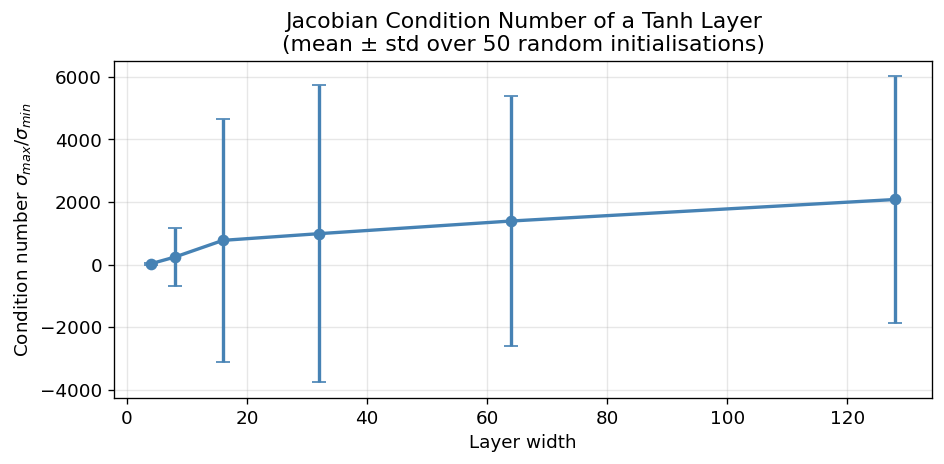

In [ ]:
# Sweep a 1-layer tanh network: vary width, measure Jacobian condition number
torch.manual_seed(0)

widths = [4, 8, 16, 32, 64, 128]
n_trials = 50
cond_means, cond_stds = [], []
sv_max_means = []

for w in widths:
    conds = []
    for _ in range(n_trials):
        net = nn.Sequential(nn.Linear(w, w), nn.Tanh())
        x = torch.randn(w)
        J = torch_jacobian(net, x)  # (w, w)
        svs = torch.linalg.svdvals(J)
        conds.append((svs.max() / (svs.min() + 1e-12)).item())
    cond_means.append(np.mean(conds))
    cond_stds.append(np.std(conds))

fig, ax = plt.subplots(figsize=(8, 4))
ax.errorbar(
    widths,
    cond_means,
    yerr=cond_stds,
    marker="o",
    capsize=4,
    color="steelblue",
    linewidth=2,
)
ax.set_xlabel("Layer width")
ax.set_ylabel("Condition number $\\sigma_{max}/\\sigma_{min}$")
ax.set_title(
    "Jacobian Condition Number of a Tanh Layer\n(mean ± std over 50 random initialisations)"
)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

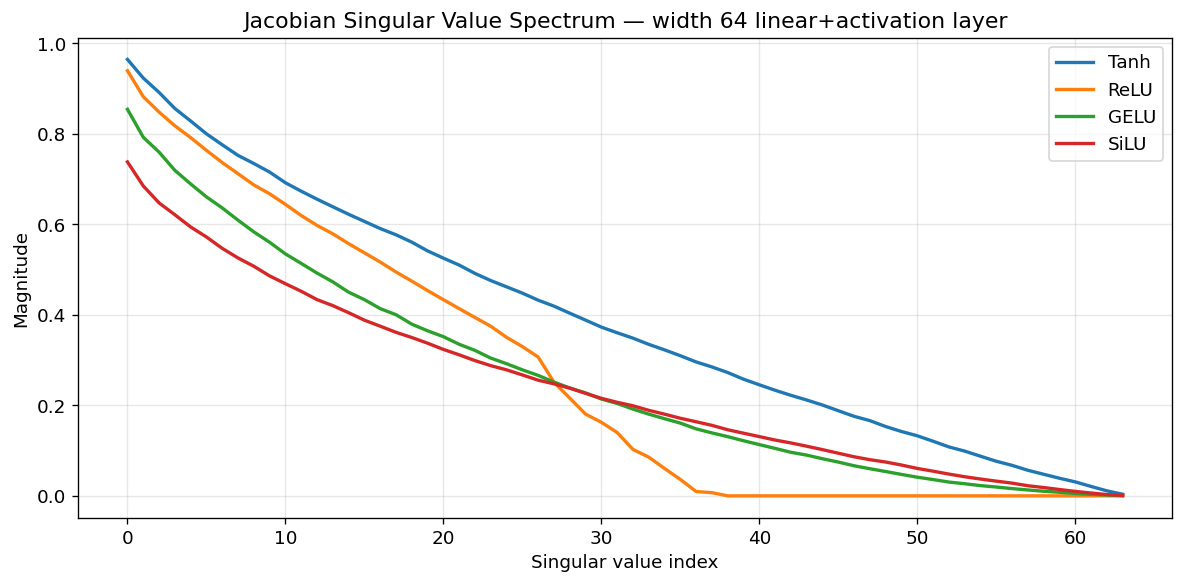

In [ ]:
# Singular value spectra for different activations — same architecture
torch.manual_seed(1)
W = 64
activation_classes = {
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "GELU": nn.GELU(),
    "SiLU": nn.SiLU(),
}

fig, ax = plt.subplots(figsize=(10, 5))
for name, act in activation_classes.items():
    all_svs = []
    for _ in range(20):
        net = nn.Sequential(nn.Linear(W, W), act)
        x = torch.randn(W)
        J = torch_jacobian(net, x)
        svs = torch.linalg.svdvals(J).detach().numpy()
        all_svs.append(svs)
    sv_arr = np.array(all_svs).mean(axis=0)
    ax.plot(sv_arr, label=name, linewidth=2)

ax.set_xlabel("Singular value index")
ax.set_ylabel("Magnitude")
ax.set_title(f"Jacobian Singular Value Spectrum — width {W} linear+activation layer")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 15 · Newton's Method via the Jacobian

Find $\mathbf{x}^*$ such that $f(\mathbf{x}^*) = \mathbf{0}$ using the update:

$$\mathbf{x}_{k+1} = \mathbf{x}_k - J_f(\mathbf{x}_k)^{-1}\, f(\mathbf{x}_k)$$

Quadratic convergence when $J_f$ is non-singular near the root.

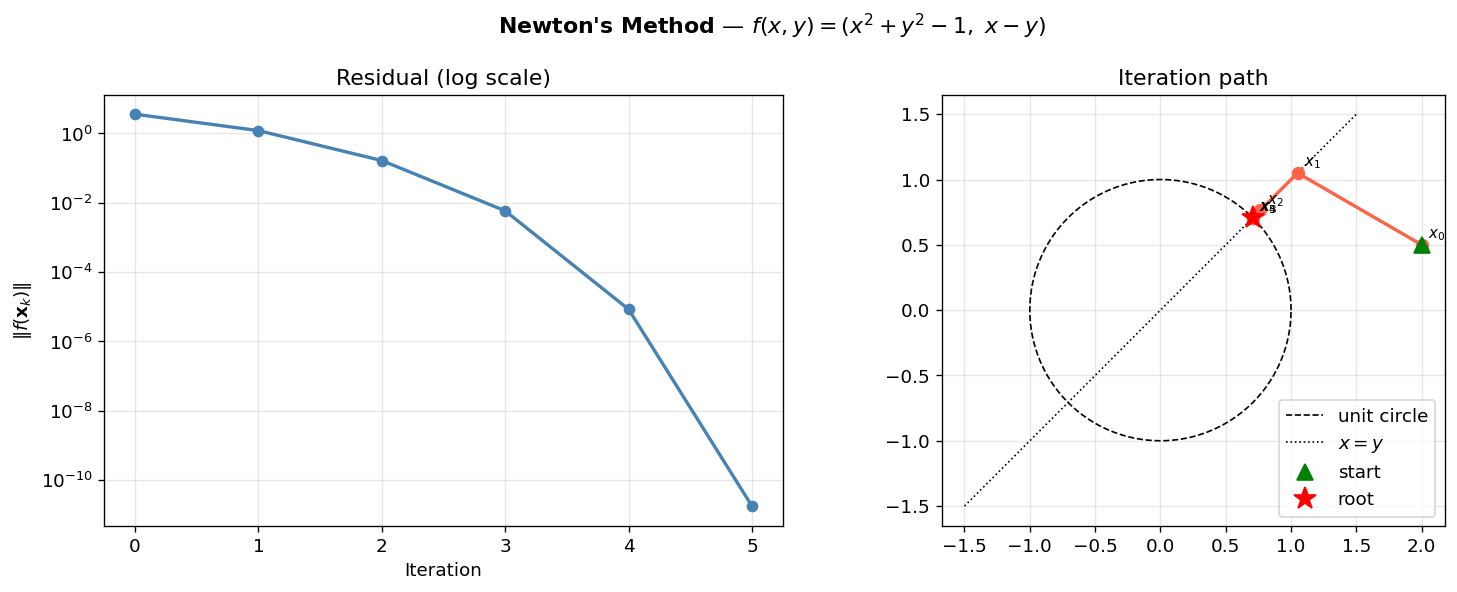

Converged in 6 iterations.  Root ≈ [0.70710678 0.70710678]
Residual at root: 1.77e-11


In [ ]:
def newton(f, J_fn, x0, tol=1e-10, max_iter=30):
    x = x0.copy().astype(float)
    history = [x.copy()]
    residuals = []
    for _ in range(max_iter):
        fx = f(x)
        residuals.append(np.linalg.norm(fx))
        if residuals[-1] < tol:
            break
        x = x - np.linalg.solve(J_fn(x), fx)
        history.append(x.copy())
    return np.array(history), np.array(residuals)


# Root of f(x,y) = (x^2 + y^2 - 1,  x - y)   → roots at (±1/√2, ±1/√2)
def f_circ(x):
    return np.array([x[0] ** 2 + x[1] ** 2 - 1, x[0] - x[1]])


def J_circ(x):
    return np.array([[2 * x[0], 2 * x[1]], [1.0, -1.0]])


hist, res = newton(f_circ, J_circ, x0=np.array([2.0, 0.5]))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Newton's Method — $f(x,y)=(x^2+y^2-1,\ x-y)$", fontweight="bold")

# Convergence
axes[0].semilogy(res, "o-", color="steelblue", linewidth=2)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("$\\|f(\\mathbf{x}_k)\\|$")
axes[0].set_title("Residual (log scale)")
axes[0].grid(True, alpha=0.3)

# Path in the plane
th = np.linspace(0, 2 * np.pi, 300)
axes[1].plot(np.cos(th), np.sin(th), "k--", lw=1, label="unit circle")
axes[1].plot([-1.5, 1.5], [-1.5, 1.5], "k:", lw=1, label="$x=y$")
axes[1].plot(hist[:, 0], hist[:, 1], "o-", color="tomato", lw=2, ms=7)
axes[1].plot(*hist[0], "g^", ms=10, label="start")
axes[1].plot(*hist[-1], "r*", ms=14, label="root")
for i, pt in enumerate(hist):
    axes[1].annotate(f"$x_{i}$", pt, xytext=pt + np.array([0.05, 0.05]), fontsize=9)
axes[1].set_aspect("equal")
axes[1].legend()
axes[1].set_title("Iteration path")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Converged in {len(res)} iterations.  Root ≈ {hist[-1].round(10)}")
print(f"Residual at root: {res[-1]:.2e}")

## 16 · Summary

| Concept | Formula | Geometric meaning |
|---|---|---|
| Fréchet derivative | $f(\mathbf{x}+\mathbf{h}) \approx f(\mathbf{x}) + J_f \mathbf{h}$ | Best linear approximation to $f$ at $\mathbf{x}$ |
| Jacobian entry | $(J_f)_{ij} = \partial f_i / \partial x_j$ | Sensitivity of output $i$ to input $j$ |
| Jacobian column $j$ | $J_f \mathbf{e}_j$ | Image of basis vector $\mathbf{e}_j$ under $Df$ |
| $\|\det J_f\|$ | Area/volume scaling factor | How much $f$ locally expands or contracts |
| $\det J_f = 0$ | Singular — rank-deficient | $f$ locally collapses a dimension |
| $\det J_f < 0$ | Orientation-reversing | $f$ includes a reflection component |
| Chain rule | $J_{f \circ g} = J_f \cdot J_g$ | Backpropagation is this product, right-to-left |
| VJP $\mathbf{u}^\top J$ | Reverse-mode AD | $O(1)$ passes for scalar output |
| JVP $J \mathbf{v}$ | Forward-mode AD | $O(1)$ passes for single input direction |